# Fraud Detection Assignment
Pipeline ini mencakup EDA, Preprocessing, Hyperparameter Tuning (Optuna), dan Experiment Tracking (MLflow) menggunakan CatBoost dengan dukungan GPU.

In [1]:
!pip install catboost optuna mlflow

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import mlflow
import mlflow.catboost
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset
Mount Google Drive dan muat data `train_transaction.csv`.

In [3]:
drive.mount('/content/drive')
path = '/content/drive/MyDrive/MLUTS/train_transaction.csv'
df = pd.read_csv(path)
print(f'Shape dataset: {df.shape}')
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape dataset: (590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Exploratory Data Analysis (EDA)
Visualisasi distribusi target, missing values, dan jumlah transaksi.

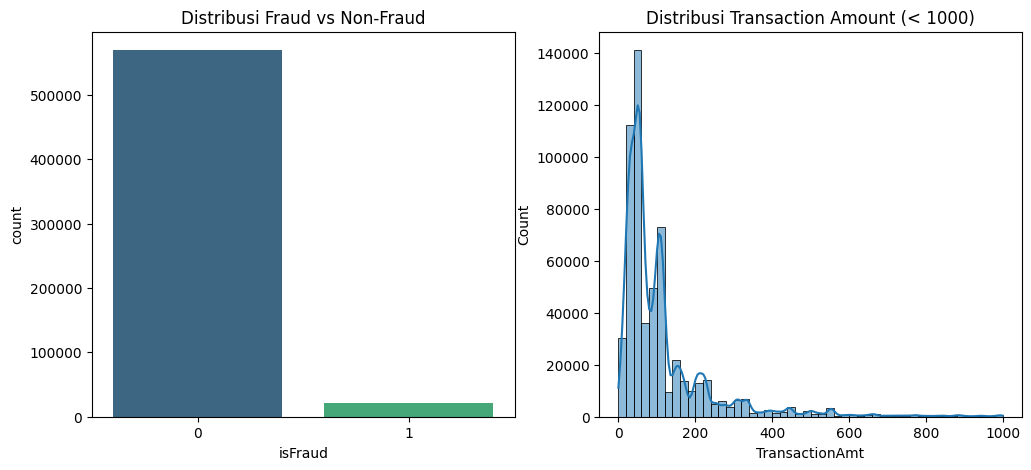

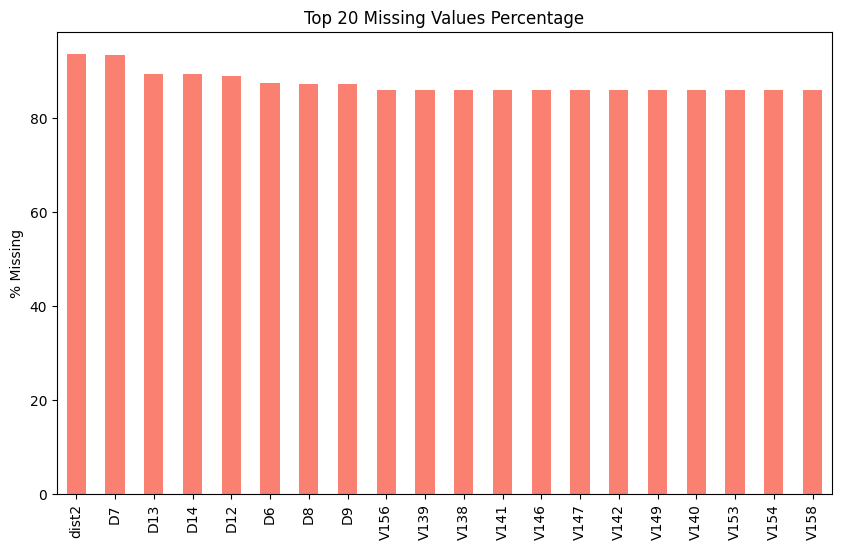

In [4]:
plt.figure(figsize=(12, 5))

# Target Distribution
plt.subplot(1, 2, 1)
sns.countplot(x='isFraud', data=df, palette='viridis')
plt.title('Distribusi Fraud vs Non-Fraud')

# Transaction Amount Distribution
plt.subplot(1, 2, 2)
sns.histplot(df[df['TransactionAmt'] < 1000]['TransactionAmt'], bins=50, kde=True)
plt.title('Distribusi Transaction Amount (< 1000)')
plt.show()

# Missing Values Chart (Top 20 columns)
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)[:20]
plt.figure(figsize=(10, 6))
missing.plot(kind='bar', color='salmon')
plt.title('Top 20 Missing Values Percentage')
plt.ylabel('% Missing')
plt.show()

## 4. Data Cleaning & Preprocessing
Menangani missing values sederhana dan encoding kategori.

In [5]:
# Drop columns with > 80% missing values
null_cols = [c for c in df.columns if df[c].isnull().mean() > 0.8]
df = df.drop(columns=null_cols)

# Fill numerical with median and categorical with 'Unknown'
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(exclude=['object']).columns.tolist()
num_cols.remove('isFraud')

df[cat_cols] = df[cat_cols].fillna('Unknown')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Encode categorical columns to string for CatBoost
for col in cat_cols:
    df[col] = df[col].astype(str)

## 5. Train/Validation/Test Split
Membagi data dengan stratify karena imbalance.

In [6]:
X = df.drop(['isFraud', 'TransactionID'], axis=1)
y = df['isFraud']

# Split 70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f'Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}')

Train size: 413378, Val size: 88581, Test size: 88581


## 6. Optuna Hyperparameter Tuning
Mengoptimasi ROC-AUC dengan 10 trials.

In [7]:
def objective(trial):
    params = {
        'iterations': 500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'task_type': 'GPU',
        'auto_class_weights': 'Balanced',
        'verbose': False,
        'eval_metric': 'AUC'
    }

    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols, early_stopping_rounds=50)
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

[I 2026-05-14 20:14:11,918] A new study created in memory with name: no-name-256439cc-a7c0-46dd-9228-3103921c6b03
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-05-14 20:15:25,269] Trial 0 finished with value: 0.9511880814110362 and parameters: {'learning_rate': 0.18216019047495732, 'depth': 8, 'l2_leaf_reg': 2.4700941351326158}. Best is trial 0 with value: 0.9511880814110362.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-05-14 20:16:55,299] Trial 1 finished with value: 0.949131819898857 and parameters: {'learning_rate': 0.2942710682206801, 'depth': 9, 'l2_leaf_reg': 3.3540377659058622}. Best is trial 0 with value: 0.9511880814110362.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-05-14 20:17:57,571] Trial 2 finished with value: 0.9410661225980796 and parameters: {'learning_rate': 0.06410802655529471, 'depth': 7, 'l2_leaf_reg': 8.494779855142898}. Best is trial 0 with value: 0.9511880814110362

## 7. Final Training & MLflow Tracking
Melatih model terbaik dan mencatat log ke MLflow.

In [8]:
mlflow.set_experiment("Fraud_Detection_Assignment")

with mlflow.start_run():
    best_params = study.best_params
    best_params.update({'task_type': 'GPU', 'auto_class_weights': 'Balanced', 'iterations': 1000, 'eval_metric': 'AUC'})

    final_model = CatBoostClassifier(**best_params)
    final_model.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols, verbose=100)

    # Evaluations
    val_auc = roc_auc_score(y_val, final_model.predict_proba(X_val)[:, 1])
    test_probs = final_model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, test_probs)

    # Log to MLflow
    mlflow.log_params(study.best_params)
    mlflow.log_metric("val_auc", val_auc)
    mlflow.log_metric("test_auc", test_auc)
    mlflow.catboost.log_model(final_model, "model")

    print(f'Final Test AUC: {test_auc}')

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8458820	best: 0.8458820 (0)	total: 208ms	remaining: 3m 27s
100:	test: 0.9276178	best: 0.9276178 (100)	total: 15.4s	remaining: 2m 17s
200:	test: 0.9406627	best: 0.9406627 (200)	total: 31.1s	remaining: 2m 3s
300:	test: 0.9478592	best: 0.9478592 (300)	total: 46.8s	remaining: 1m 48s
400:	test: 0.9519809	best: 0.9519809 (400)	total: 1m 2s	remaining: 1m 32s
500:	test: 0.9541923	best: 0.9541923 (500)	total: 1m 17s	remaining: 1m 17s
600:	test: 0.9556109	best: 0.9556109 (600)	total: 1m 32s	remaining: 1m 1s
700:	test: 0.9568486	best: 0.9568486 (700)	total: 1m 47s	remaining: 46s
800:	test: 0.9576886	best: 0.9576886 (800)	total: 2m 3s	remaining: 30.6s
900:	test: 0.9582372	best: 0.9582372 (900)	total: 2m 18s	remaining: 15.2s
999:	test: 0.9592007	best: 0.9592007 (999)	total: 2m 33s	remaining: 0us
bestTest = 0.9592006803
bestIteration = 999


2026/05/14 20:27:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Final Test AUC: 0.962873532157594


## 8. Save Model
Menyimpan model ke local disk.

In [9]:
final_model.save_model('fraud_detection_model.cbm')
print("Model saved as fraud_detection_model.cbm")

Model saved as fraud_detection_model.cbm


## 9. Evaluasi Akhir & Visualisasi
Confusion Matrix, Classification Report, dan ROC Curve.

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     85482
           1       0.48      0.82      0.61      3099

    accuracy                           0.96     88581
   macro avg       0.74      0.90      0.79     88581
weighted avg       0.98      0.96      0.97     88581



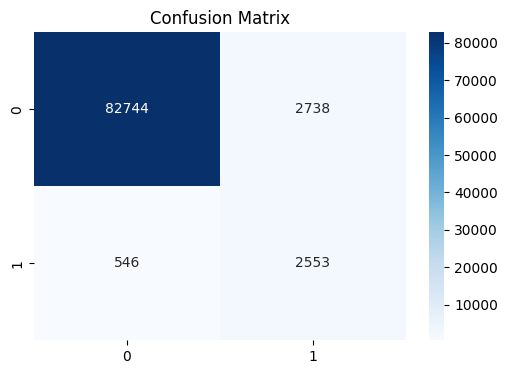

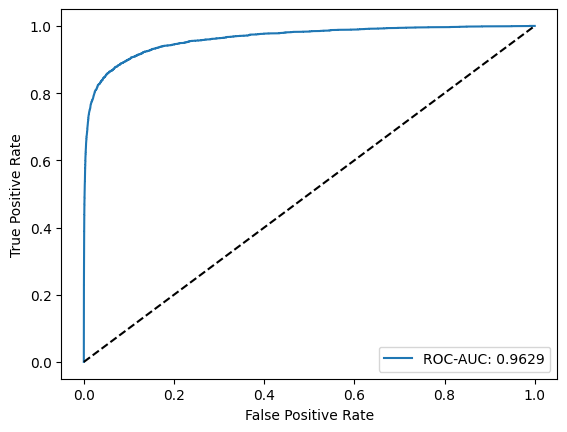

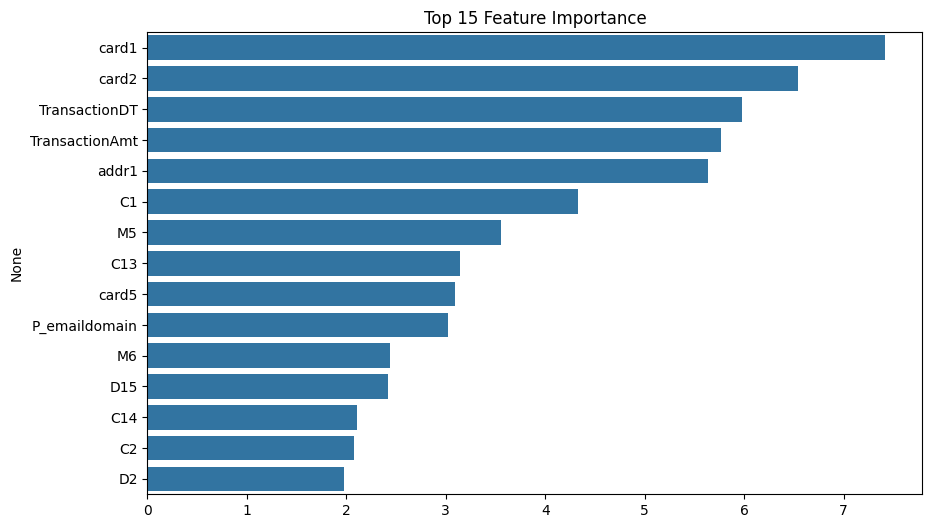

In [10]:
test_preds = final_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, test_preds))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, test_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
plt.plot(fpr, tpr, label=f'ROC-AUC: {test_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Feature Importance
feat_imp = pd.Series(final_model.get_feature_importance(), index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Top 15 Feature Importance')
plt.show()